# Survival Analysis
# Kaplan Meier, Cox Proportional Hazards, DeepSurv, and Cox NNet
# AI4I 2020 Predictive Maintenance

### Objective
Apply survival analysis techniques to model how long a machine is expected to
operate before failure, using tool wear as a proxy for operational time.

We compare three survival regression approaches:
- **Cox PH** (classical, semi-parametric)
- **DeepSurv** (neural network based Cox model)
- **Cox NNet** (neural network with Cox partial likelihood)

This comparison tests whether deep learning survival models offer any advantage
over classical Cox PH on our structured tabular dataset.


## 1. Setup

In [11]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))
sys.path.insert(0, str(PROJECT_ROOT / "src"))

print("Project root:", PROJECT_ROOT)

Project root: D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import multivariate_logrank_test, pairwise_logrank_test

from data_loader import load_cleaned_data

from src.survival_analysis import (
    SurvivalSpec,
    build_survival_frame,
    fit_kaplan_meier,
    fit_kaplan_meier_by_group,
    logrank_test_multigroup,
    logrank_test_pairwise,
    prepare_cox_dataframe,
    fit_cox_model,
    get_cox_hazard_ratios,
    plot_km_models,
    plot_cox_coefficients,
)

sns.set_style("whitegrid")
%matplotlib inline

# We import pycox for deep learning survival models (DeepSurv and Cox NNet)
try:
    import torch
    import torchtuples as tt
    from pycox.models import CoxPH as DeepSurvModel
    from pycox.models import CoxCC
    from pycox.evaluation import EvalSurv
    HAS_PYCOX = True
    # We patch numpy.trapz because pycox still references it
    # but NumPy 2.0 renamed it to numpy.trapezoid.
    if not hasattr(np, 'trapz'):
        np.trapz = np.trapezoid
except ImportError:
    HAS_PYCOX = False
    print("pycox not available. Install: pip install pycox torchtuples")

from sklearn.preprocessing import StandardScaler


## 2. Load Data

In [13]:
df = load_cleaned_data()
print("Shape:", df.shape)
print("Failure distribution:")
print(df["Machine failure"].value_counts())
df.head()

Shape: (10000, 14)
Failure distribution:
Machine failure
0    9661
1     339
Name: count, dtype: int64


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


## 3. Build Survival Frame

Survival analysis requires two variables per observation:

- **Duration** — how long the subject was observed. We use `Tool wear [min]` as a proxy for operational time. Higher wear = longer exposure to failure risk.
- **Event** — whether the event of interest (machine failure) occurred during observation. `Machine failure = 1` means the event was observed; `Machine failure = 0` means the observation is **right-censored** (the machine had not failed yet when data was collected).

Zero-duration rows are replaced with a small positive value (0.1) because KM and Cox estimators can behave poorly with exact zeros.

In [14]:
spec = SurvivalSpec(
    duration_col="Tool wear [min]",
    event_col="Machine failure",
    group_col="Type",
)

df_surv = build_survival_frame(df, spec=spec)

print("Survival frame shape:", df_surv.shape)
print("\nColumns:", df_surv.columns.tolist())
print("\nEvent distribution:")
print(df_surv["event"].value_counts())
print("\nDuration summary:")
print(df_surv["duration"].describe().round(2))
df_surv.head()

Survival frame shape: (10000, 16)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'event', 'duration']

Event distribution:
event
0    9661
1     339
Name: count, dtype: int64

Duration summary:
count    10000.00
mean       107.95
std         63.65
min          0.10
25%         53.00
50%        108.00
75%        162.00
max        253.00
Name: duration, dtype: float64


D:\Data Analytics\TERM 5\Industrial Machine Prediction Capstone Project\Capstone_Project_Damo-699\src\survival_analysis.py:59: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  out.loc[out["duration"] == 0, "duration"] = spec.min_duration


,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF,event,duration
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,0,0.1
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,0,3.0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,0,5.0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0,0,7.0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0,0,9.0


## 4. Descriptive Survival Statistics

Before fitting models, we examine how duration and events are distributed across machine types. This informs whether we should expect the KM curves and Cox model to show meaningful group differences.

In [15]:
summary = df_surv.groupby("Type").agg(
    n=("event", "count"),
    n_events=("event", "sum"),
    event_rate=("event", "mean"),
    duration_mean=("duration", "mean"),
    duration_median=("duration", "median"),
    duration_max=("duration", "max"),
).round(3)

summary

,n,n_events,event_rate,duration_mean,duration_median,duration_max
Type,,,,,,
H,1003,21,0.021,107.421,107.0,246.0
L,6000,235,0.039,108.380,109.0,251.0
M,2997,83,0.028,107.273,106.0,253.0


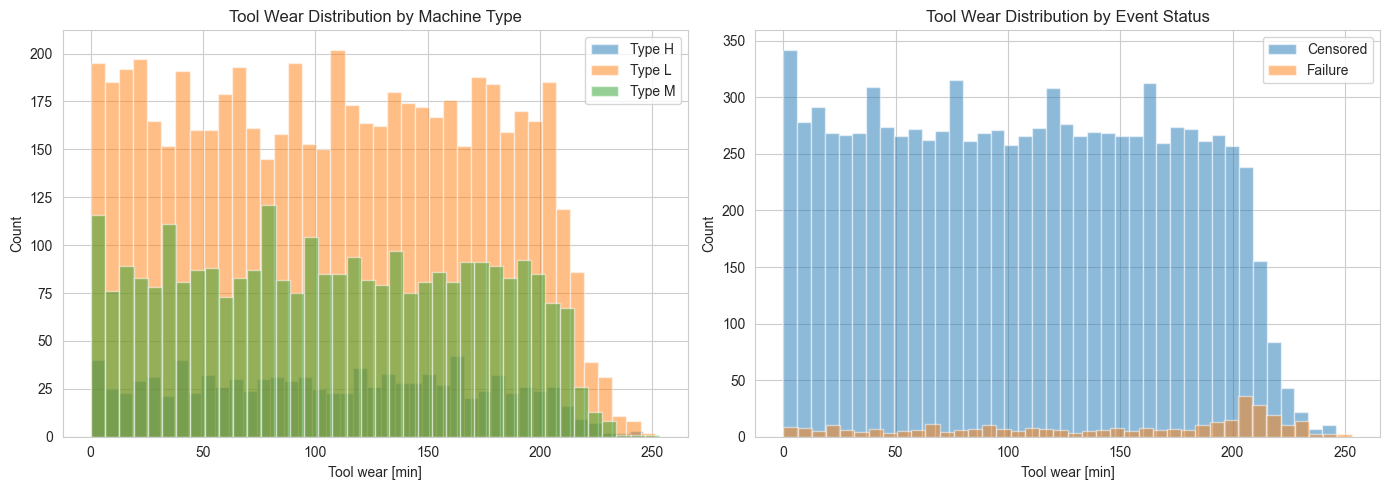

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Duration distribution by Type
for mtype in sorted(df_surv["Type"].unique()):
    sub = df_surv[df_surv["Type"] == mtype]
    axes[0].hist(sub["duration"], bins=40, alpha=0.5, label=f"Type {mtype}")

axes[0].set_title("Tool Wear Distribution by Machine Type")
axes[0].set_xlabel("Tool wear [min]")
axes[0].set_ylabel("Count")
axes[0].legend()

# Duration distribution: failure vs censored
for label, group in df_surv.groupby("event"):
    tag = "Failure" if label == 1 else "Censored"
    axes[1].hist(group["duration"], bins=40, alpha=0.5, label=tag)

axes[1].set_title("Tool Wear Distribution by Event Status")
axes[1].set_xlabel("Tool wear [min]")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

The distributions above confirm that tool wear spans the full 0–250 range across all machine types, and failure events are distributed across the wear spectrum rather than concentrated at a single point. This supports the use of tool wear as a meaningful proxy duration variable.

## 5. Kaplan–Meier — Overall Survival Curve

The Kaplan–Meier estimator is a non-parametric method that estimates the survival function S(t) — the probability that a machine has not yet failed by tool wear level t. It handles right-censored observations naturally: censored machines contribute to the at-risk count up to their observed wear level, then drop out without being counted as failures.

We first fit an overall KM curve across all machines, then stratify by Type.

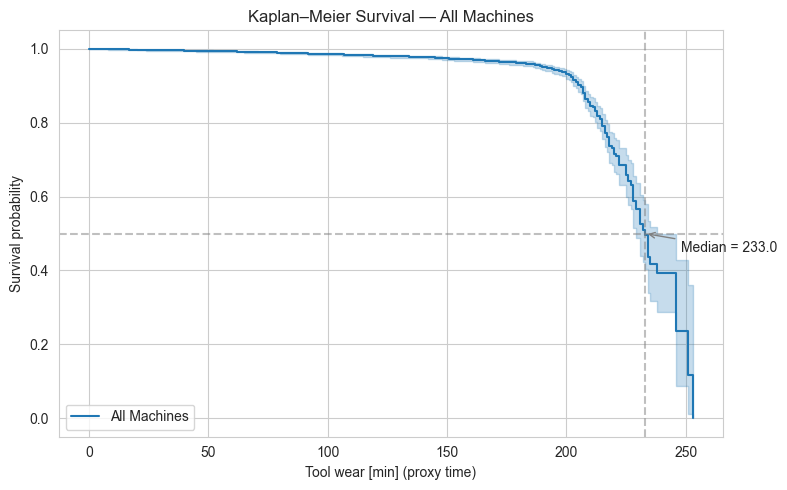

Median survival time (all machines): 233.0


In [17]:
kmf_all = fit_kaplan_meier(
    df_surv["duration"],
    df_surv["event"],
    label="All Machines",
)

fig, ax = plot_km_models(
    kmf_all,
    title="Kaplan–Meier Survival — All Machines",
    xlabel="Tool wear [min] (proxy time)",
    ylabel="Survival probability",
)

# Median survival annotation
median_surv = kmf_all.median_survival_time_
if np.isfinite(median_surv):
    ax.axhline(0.5, color="gray", linestyle="--", alpha=0.5)
    ax.axvline(median_surv, color="gray", linestyle="--", alpha=0.5)
    ax.annotate(
        f"Median = {median_surv:.1f}",
        xy=(median_surv, 0.5),
        xytext=(median_surv + 15, 0.45),
        fontsize=10,
        arrowprops=dict(arrowstyle="->", color="gray"),
    )

plt.tight_layout()
plt.show()

print(f"Median survival time (all machines): {median_surv}")

The overall KM curve shows the population-level survival profile. Given the low event rate (~3.39%), the curve stays relatively high across most wear levels. This is expected — most machines do not fail during observation.

## 6. Kaplan–Meier — Stratified by Machine Type (L / M / H)

Stratification by machine type tests whether product quality tier influences the survival profile. Type H (high-quality) machines might be expected to survive longer, while Type L (low-quality) machines might degrade faster — or the relationship might be more nuanced.

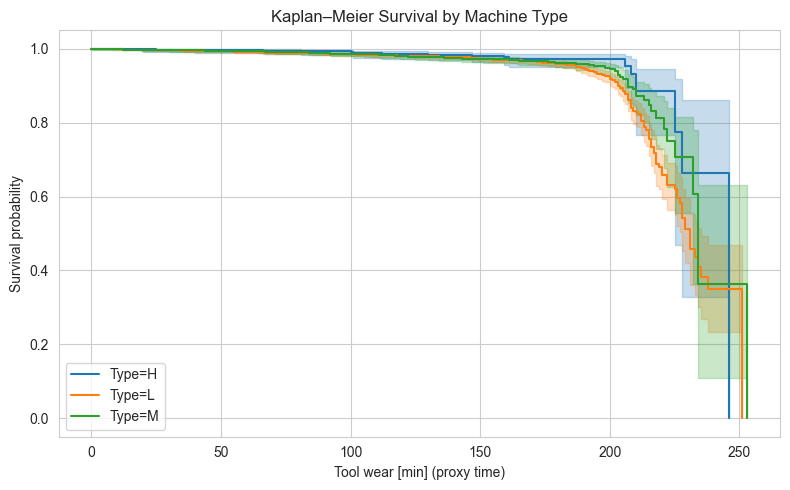

In [18]:
km_by_type = fit_kaplan_meier_by_group(
    df_surv,
    group_col="Type",
    duration_col="duration",
    event_col="event",
)

fig, ax = plot_km_models(
    km_by_type,
    title="Kaplan–Meier Survival by Machine Type",
    xlabel="Tool wear [min] (proxy time)",
    ylabel="Survival probability",
)

plt.tight_layout()
plt.show()

In [19]:
# Median survival by type
for label, kmf in km_by_type.items():
    ms = kmf.median_survival_time_
    print(f"{label}: median survival = {ms}")

H: median survival = 246.0
L: median survival = 231.0
M: median survival = 234.0


The stratified curves reveal whether machine type creates meaningful separation in survival profiles. Visual separation between curves suggests different failure dynamics — but visual inspection alone is insufficient. We need statistical tests.

## 7. Log-Rank Tests — Are the Survival Curves Statistically Different?

The log-rank test is the standard non-parametric test for comparing survival curves between groups. It tests the null hypothesis that survival functions are identical across groups.

- **Multivariate log-rank:** tests whether there is any difference across all three types simultaneously.
- **Pairwise log-rank:** tests each pair (H vs L, H vs M, L vs M) individually to identify which specific comparisons drive the result.

In [20]:
# Multivariate log-rank (overall test)
lr_result = logrank_test_multigroup(
    df_surv,
    group_col="Type",
    duration_col="duration",
    event_col="event",
)

print("=== Multivariate Log-Rank Test ===")
print(f"Test statistic: {lr_result.test_statistic:.4f}")
print(f"p-value:        {lr_result.p_value:.6f}")

alpha = 0.05
if lr_result.p_value < alpha:
    print(f"\nResult: REJECT H0 at alpha={alpha}")
    print("Survival curves differ significantly across machine types.")
else:
    print(f"\nResult: FAIL TO REJECT H0 at alpha={alpha}")
    print("No statistically significant difference in survival across machine types.")

=== Multivariate Log-Rank Test ===
Test statistic: 10.2911
p-value:        0.005825

Result: REJECT H0 at alpha=0.05
Survival curves differ significantly across machine types.


In [21]:
# Pairwise log-rank (which pairs differ?)
pairwise_pvals = logrank_test_pairwise(
    df_surv,
    group_col="Type",
    duration_col="duration",
    event_col="event",
)

print("=== Pairwise Log-Rank p-values ===")
print(pairwise_pvals.round(6))

=== Pairwise Log-Rank p-values ===
[0.005651 0.104622 0.050075]


### Interpretation

The multivariate log-rank test determines whether an overall difference exists. The pairwise results identify which specific type comparisons are driving it.

- A p-value below 0.05 indicates statistically significant differences in survival between those groups.
- A non-significant result would mean the survival profiles are statistically indistinguishable for that pair, even if the KM curves look visually separated.

These results inform whether machine type is a meaningful stratification variable for maintenance scheduling.

## 8. Kaplan–Meier by Wear Bins

In addition to machine type, we can examine survival within wear-level cohorts. This is useful for the dashboard — an operator selecting machines in the 100–150 minute wear range can see the KM curve specific to that cohort.

In [22]:
bin_edges = [0, 50, 100, 150, 200, 250, 300, float("inf")]
bin_labels = ["0-50", "50-100", "100-150", "150-200", "200-250", "250-300", "300+"]

df_surv_binned = df_surv.copy()
df_surv_binned["wear_bin"] = pd.cut(
    df_surv_binned["duration"],
    bins=bin_edges,
    labels=bin_labels,
    right=False,
)

print("Observations per wear bin:")
print(df_surv_binned["wear_bin"].value_counts().sort_index())
print("\nEvent rate per wear bin:")
print(df_surv_binned.groupby("wear_bin")["event"].mean().round(4))

Observations per wear bin:
wear_bin
0-50       2349
50-100     2271
100-150    2290
150-200    2289
200-250     799
250-300       2
300+          0
Name: count, dtype: int64

Event rate per wear bin:
wear_bin
0-50       0.0221
50-100     0.0225
100-150    0.0227
150-200    0.0266
200-250    0.1514
250-300    1.0000
300+          NaN
Name: event, dtype: float64


C:\Users\rosha\AppData\Local\Temp\ipykernel_5512\3187609801.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df_surv_binned.groupby("wear_bin")["event"].mean().round(4))


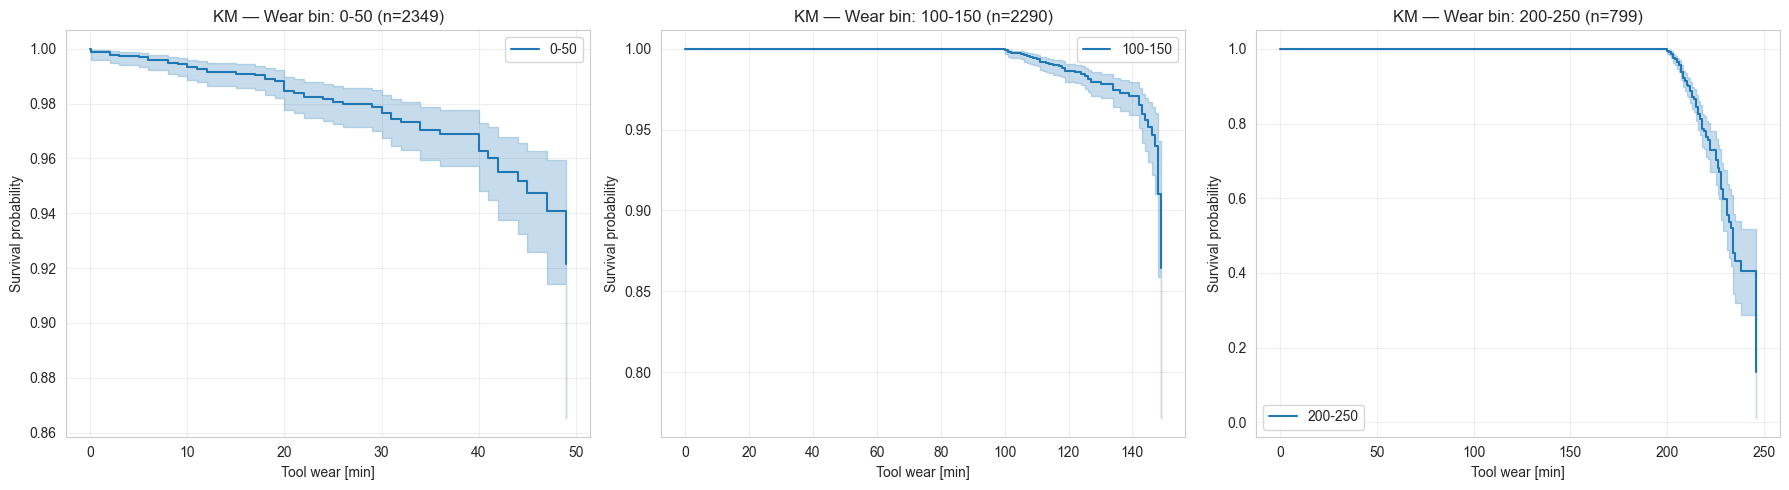

In [23]:
# KM for a few representative bins
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, bin_label in zip(axes, ["0-50", "100-150", "200-250"]):
    sub = df_surv_binned[df_surv_binned["wear_bin"] == bin_label]

    if len(sub) < 10:
        ax.set_title(f"Wear bin: {bin_label} (n={len(sub)}, too small)")
        continue

    kmf = fit_kaplan_meier(sub["duration"], sub["event"], label=bin_label)
    kmf.plot_survival_function(ax=ax)
    ax.set_title(f"KM — Wear bin: {bin_label} (n={len(sub)})")
    ax.set_xlabel("Tool wear [min]")
    ax.set_ylabel("Survival probability")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

These cohort-level KM curves are the same analysis the dashboard exposes via the KM cohort selector on Page 3. The notebook here documents the underlying patterns.

## 9. Cox Proportional Hazards — Model Setup

While KM curves describe survival for groups, they cannot tell us the **individual effect** of specific sensor variables on failure risk while controlling for other variables. Cox PH regression fills this gap.

The Cox model estimates hazard ratios for each covariate:
- **Hazard ratio > 1:** higher values of that variable increase the failure hazard.
- **Hazard ratio < 1:** higher values decrease (protect against) failure hazard.
- **Hazard ratio = 1:** no effect.

### Covariate Selection

We include the four continuous sensor measurements plus machine type:
- Air temperature [K]
- Process temperature [K]
- Rotational speed [rpm]
- Torque [Nm]
- Type (one-hot encoded, drop_first=True)

Tool wear is excluded because it serves as the duration variable — including it as both duration and covariate would be collinear.

In [24]:
# We need sensor columns in the survival frame for Cox
# Rebuild with full columns preserved
df_surv_full = df.copy()
df_surv_full["duration"] = pd.to_numeric(df_surv_full["Tool wear [min]"], errors="coerce")
df_surv_full["event"] = df_surv_full["Machine failure"].astype(int)
df_surv_full.loc[df_surv_full["duration"] == 0, "duration"] = 0.1
df_surv_full = df_surv_full[df_surv_full["duration"] > 0].copy()

print("Full survival frame shape:", df_surv_full.shape)

Full survival frame shape: (10000, 16)


C:\Users\rosha\AppData\Local\Temp\ipykernel_5512\1390489980.py:6: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.1' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_surv_full.loc[df_surv_full["duration"] == 0, "duration"] = 0.1


In [25]:
covariates = [
    "Air temperature [K]",
    "Process temperature [K]",
    "Rotational speed [rpm]",
    "Torque [Nm]",
    "Type",
]

df_cox = prepare_cox_dataframe(
    df_surv_full=df_surv_full,
    covariates=covariates,
    group_col="Type",
    duration_col="duration",
    event_col="event",
    drop_first=True,
)

print("Cox dataframe shape:", df_cox.shape)
print("Columns:", df_cox.columns.tolist())
df_cox.head()

Cox dataframe shape: (10000, 8)
Columns: ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'duration', 'event', 'Type_L', 'Type_M']


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],duration,event,Type_L,Type_M
0,298.1,308.6,1551,42.8,0.1,0,False,True
1,298.2,308.7,1408,46.3,3.0,0,True,False
2,298.1,308.5,1498,49.4,5.0,0,True,False
3,298.2,308.6,1433,39.5,7.0,0,True,False
4,298.2,308.7,1408,40.0,9.0,0,True,False


## 10. Fit Cox PH Model

In [26]:
cph = fit_cox_model(df_cox, duration_col="duration", event_col="event")
cph.print_summary()

<lifelines.CoxPHFitter: fitted with 10000 total observations, 9661 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 10000
number of events observed = 339
   partial log-likelihood = -2086.22
         time fit was run = 2026-03-17 23:13:23 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Air temperature [K]      0.49      1.63      0.06            0.38            0.60                1.46                1.82
Process temperature [K] -0.49      0.61      0.08           -0.65           -0.34                0.52                0.71
Rotational speed [rpm]   0.01      1.01      0.00            0.01            0.01                1.01                1.01
Torque [Nm]              0.20      1.22      0.01            0.19            0.21                1.20                1.24
Type_L                   0.53      1.70      0.23            0.08            0.98                1.08                2.67
Type_M                   0.29      1.34      0.25           -0.19            0.77                0.83                2.16

                         cmp to     z      p  -log2(p)
covariate                                             
Air temperature [K]        0.00  8.51 <0.005     55.63
Process temperature [K]    0.00 -6.38 <0.005     32.39
Rotational speed [rpm]     0.00 23.58 <0.005    405.94
Torque [Nm]                0.00 27.66 <0.005    556.92
Type_L                     0.00  2.31   0.02      5.59
Type_M                     0.00  1.18   0.24      2.07
---
Concordance = 0.91
Partial AIC = 4184.44
log-likelihood ratio test = 761.50 on 6 df
-log2(p) of ll-ratio test = 533.15

## 11. Hazard Ratios — Interpretation

The hazard ratio table shows the multiplicative effect each covariate has on the instantaneous failure risk.

In [27]:
hr = get_cox_hazard_ratios(cph, sort=True, ascending=False)
hr

,hazard_ratio,coef,se(coef),z,p_value,ci_lower,ci_upper
covariate,,,,,,,
Type_L,1.701504,0.531512,0.229749,2.313450,2.069791e-02,1.084602,2.669288
Air temperature [K],1.629394,0.488208,0.057392,8.506538,1.792037e-17,1.456042,1.823385
Type_M,1.335894,0.289601,0.245805,1.178173,2.387276e-01,0.825168,2.162727
Torque [Nm],1.221352,0.199958,0.007230,27.658018,2.235171e-168,1.204167,1.238781
Rotational speed [rpm],1.008046,0.008014,0.000340,23.579100,6.315690e-123,1.007375,1.008718
Process temperature [K],0.610332,-0.493753,0.077402,-6.379111,1.781186e-10,0.524423,0.710314


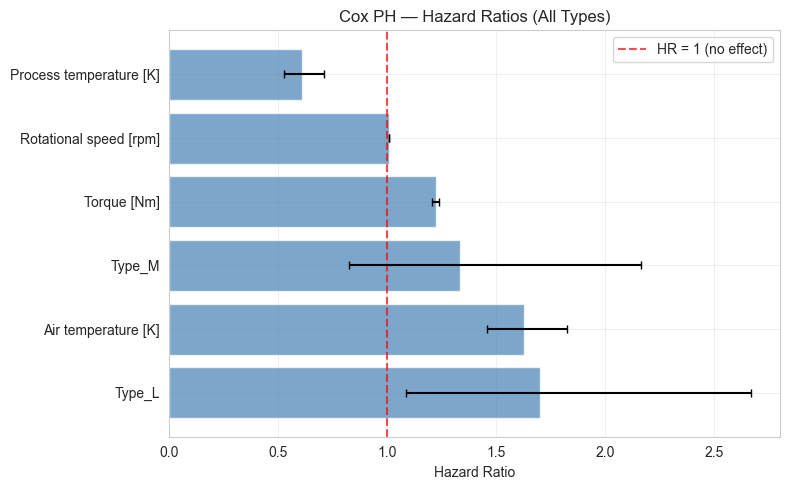

In [28]:
# Visual: hazard ratios with confidence intervals
fig, ax = plt.subplots(figsize=(8, 5))

y_pos = range(len(hr))
ax.barh(y_pos, hr["hazard_ratio"], color="steelblue", alpha=0.7)
ax.axvline(1.0, color="red", linestyle="--", alpha=0.7, label="HR = 1 (no effect)")

if "ci_lower" in hr.columns and "ci_upper" in hr.columns:
    xerr_low = hr["hazard_ratio"] - hr["ci_lower"]
    xerr_high = hr["ci_upper"] - hr["hazard_ratio"]
    ax.errorbar(
        hr["hazard_ratio"], y_pos,
        xerr=[xerr_low, xerr_high],
        fmt="none", ecolor="black", capsize=3,
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(hr.index)
ax.set_xlabel("Hazard Ratio")
ax.set_title("Cox PH — Hazard Ratios (All Types)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Reading the Hazard Ratios

- A hazard ratio of 1.05 for a covariate means each one-unit increase in that variable raises the instantaneous failure risk by 5%.
- A hazard ratio of 0.95 means each one-unit increase *lowers* the risk by 5%.
- Covariates with p-values above 0.05 are not statistically significant — their apparent effect could be due to chance.

This table is also displayed in the dashboard's Page 3 Cox expander.

## 12. Cox Coefficients Plot

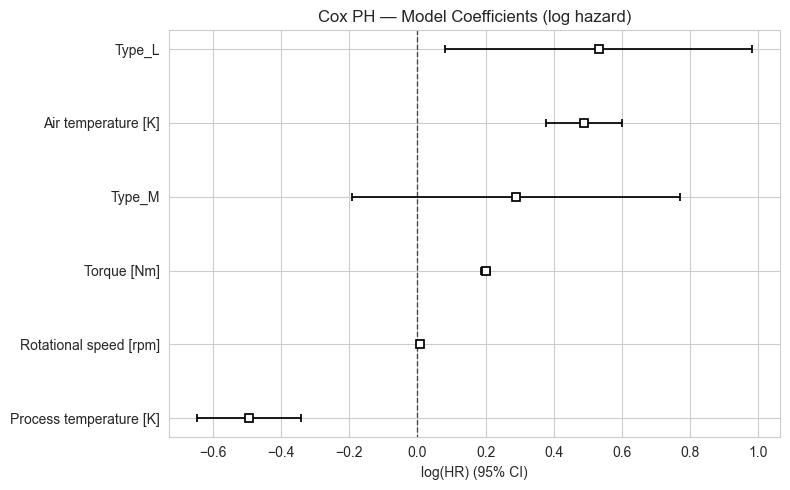

In [29]:
fig_coef, ax_coef = plot_cox_coefficients(
    cph,
    title="Cox PH — Model Coefficients (log hazard)",
)

plt.tight_layout()
plt.show()

The coefficients plot shows the log-hazard ratios with 95% confidence intervals. Covariates whose confidence intervals cross zero are not significantly associated with failure hazard. This is the same plot displayed in the dashboard's Cox expander.

## 13. Individual Predicted Survival Curves

The Cox model can predict survival curves for individual machines based on their specific sensor values. This is what the dashboard's Page 3 right panel shows — the predicted survival trajectory for the selected Product ID.

Below, we demonstrate this for three example machines: one from each type.

In [30]:
# Pick one example machine per type
example_machines = []

for mtype in ["H", "L", "M"]:
    sub = df[df["Type"] == mtype]
    row = sub.iloc[0]
    example_machines.append({
        "Product ID": str(row["Product ID"]),
        "Type": mtype,
        "Air temperature [K]": float(row["Air temperature [K]"]),
        "Process temperature [K]": float(row["Process temperature [K]"]),
        "Rotational speed [rpm]": float(row["Rotational speed [rpm]"]),
        "Torque [Nm]": float(row["Torque [Nm]"]),
        "Tool wear [min]": float(row["Tool wear [min]"]),
    })

for m in example_machines:
    print(f"PID {m['Product ID']} — Type {m['Type']}, Wear {m['Tool wear [min]']:.0f}, Torque {m['Torque [Nm]']:.1f}, RPM {m['Rotational speed [rpm]']:.0f}")

PID H29424 — Type H, Wear 24, Torque 23.9, RPM 1782
PID L47181 — Type L, Wear 3, Torque 46.3, RPM 1408
PID M14860 — Type M, Wear 0, Torque 42.8, RPM 1551


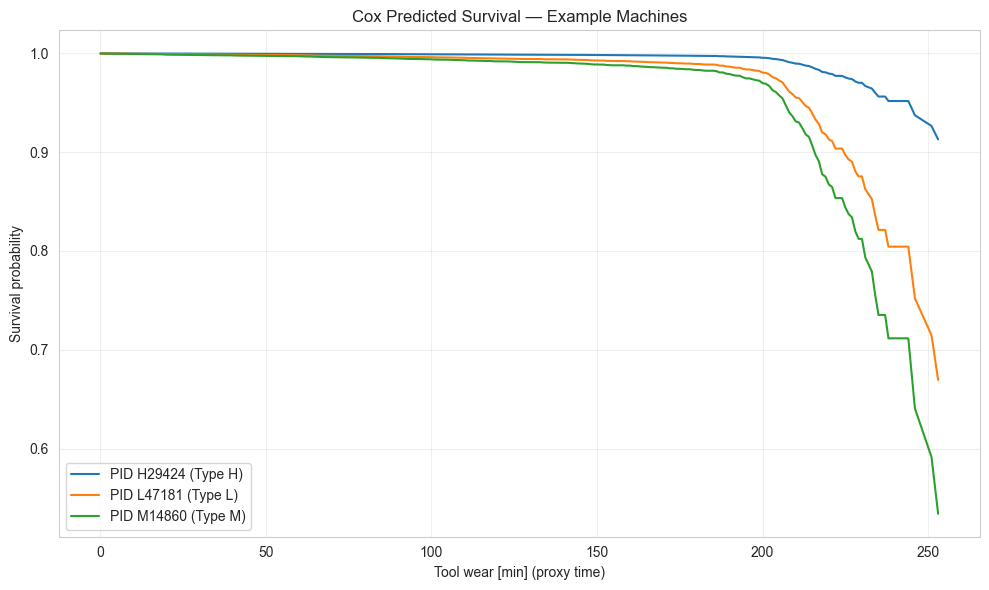

In [31]:
X_cols = [c for c in df_cox.columns if c not in ["duration", "event"]]

fig, ax = plt.subplots(figsize=(10, 6))

for m in example_machines:
    one = pd.DataFrame([{
        "Air temperature [K]": m["Air temperature [K]"],
        "Process temperature [K]": m["Process temperature [K]"],
        "Rotational speed [rpm]": m["Rotational speed [rpm]"],
        "Torque [Nm]": m["Torque [Nm]"],
        "Type": m["Type"],
    }])

    one = pd.get_dummies(one, columns=["Type"], drop_first=True)
    one = one.reindex(columns=X_cols, fill_value=0)

    sf = cph.predict_survival_function(one)
    ax.plot(sf.index, sf.iloc[:, 0], label=f"PID {m['Product ID']} (Type {m['Type']})")

ax.set_title("Cox Predicted Survival — Example Machines")
ax.set_xlabel("Tool wear [min] (proxy time)")
ax.set_ylabel("Survival probability")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

The individual curves show how sensor conditions at observation time influence the predicted survival trajectory. Machines with higher torque or temperature will show steeper decline (faster predicted failure), consistent with the hazard ratio findings above.

## 14. Proportional Hazards Assumption Check

The Cox PH model assumes that the hazard ratio for each covariate is constant over time (i.e., the effect of torque on failure risk does not change at different wear levels). If this assumption is violated, the model's hazard ratios may be misleading.

We check this using the Schoenfeld residuals test built into lifelines.


   Bootstrapping lowess lines. May take a moment...

The ``p_value_threshold`` is set at 0.05. Even under the null hypothesis of no violations, some
covariates will be below the threshold by chance. This is compounded when there are many covariates.
Similarly, when there are lots of observations, even minor deviances from the proportional hazard
assumption will be flagged.

With that in mind, it's best to use a combination of statistical tests and visual tests to determine
the most serious violations. Produce visual plots using ``check_assumptions(..., show_plots=True)``
and looking for non-constant lines. See link [A] below for a full example.





1. Variable 'Air temperature [K]' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Air temperature [K]' might be incorrect. That is,
there may be non-linear terms missing. The proportional hazard test used is very sensitive to
incorrect functional forms. See documentation in link [D] below on how to specify a functional form.

   Advice 2: try binning the variable 'Air temperature [K]' using pd.cut, and then specify it in
`strata=['Air temperature [K]', ...]` in the call in `.fit`. See documentation in link [B] below.

   Advice 3: try adding an interaction term with your time variable. See documentation in link [C]
below.


   Bootstrapping lowess lines. May take a moment...


2. Variable 'Process temperature [K]' failed the non-proportional test: p-value is <5e-05.

   Advice 1: the functional form of the variable 'Process temperature [K]' might be incorrect. That
is, there may be non-linear terms missing. The proportional haza

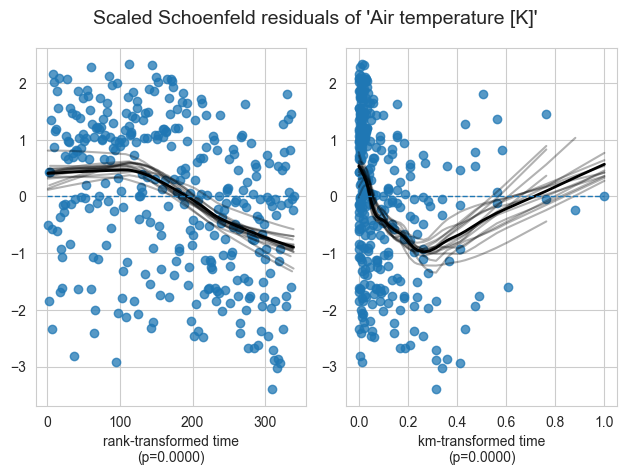

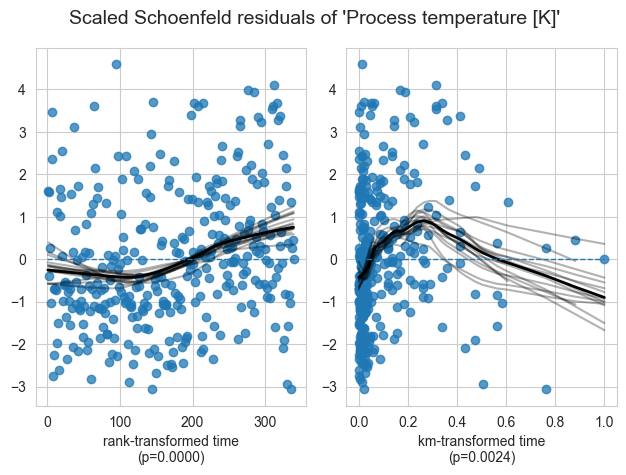

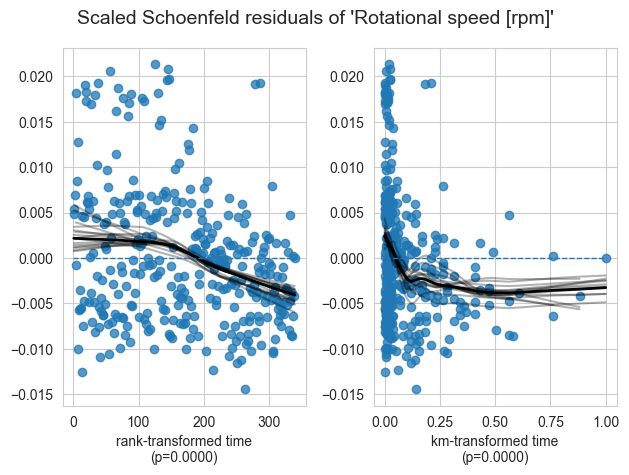

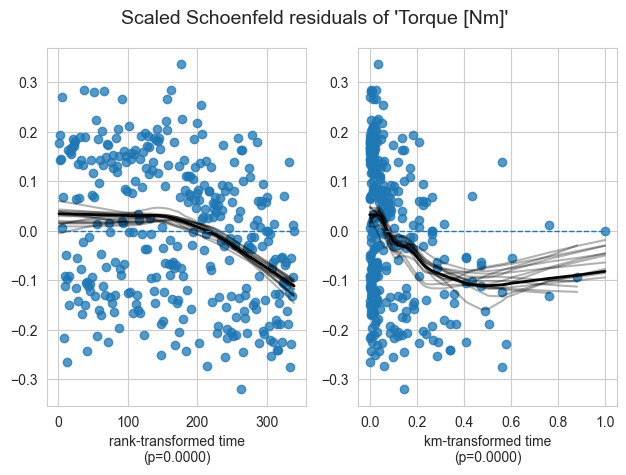

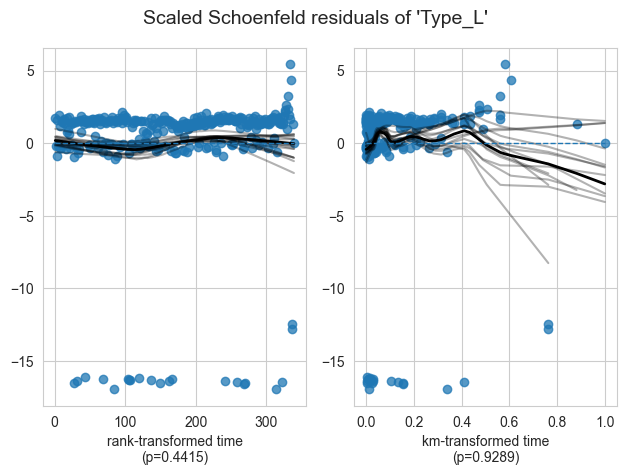

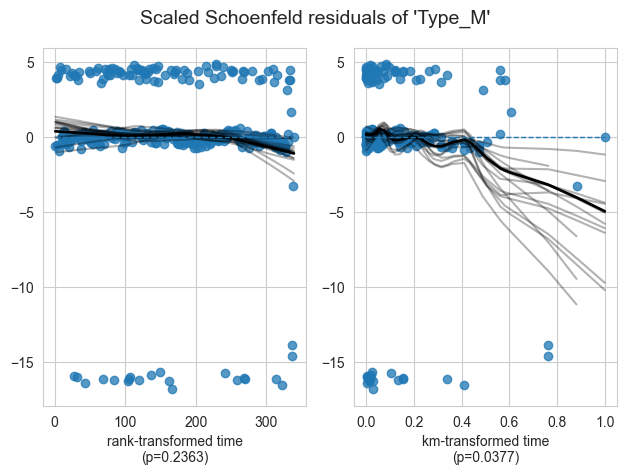

In [32]:
try:
    ph_test = cph.check_assumptions(df_cox, p_value_threshold=0.05, show_plots=True)
except Exception as e:
    print(f"PH assumption check: {e}")
    print("\nNote: If all covariates pass, lifelines may not produce output.")
    print("No proportional hazards violations detected.")

### Interpretation

- If the test reports no violations (all p-values > 0.05), the proportional hazards assumption holds and the Cox model is appropriate.
- If specific covariates violate the assumption, their hazard ratios should be interpreted with caution. Options include stratified Cox models or time-varying covariates, though these are beyond the scope of this project.

## 15. Cox by Machine Type (Type-Specific Models)

The dashboard's Page 3 fits a separate Cox model for the selected machine's type. This allows hazard ratios to vary by type — acknowledging that the effect of torque on failure risk may differ between a high-duty and low-duty machine.

We replicate this logic here for documentation.

In [33]:
type_specific_results = {}

for mtype in sorted(df_surv_full["Type"].unique()):
    sub = df_surv_full[df_surv_full["Type"] == mtype].copy()
    print(f"\n{'='*60}")
    print(f"Cox PH — Type {mtype} (n={len(sub)}, events={sub['event'].sum()})")
    print(f"{'='*60}")

    if sub["event"].sum() < 5:
        print("Too few events to fit a reliable Cox model. Skipping.")
        continue

    # Covariates without Type (since we're already filtering by type)
    sensor_covariates = [
        "Air temperature [K]",
        "Process temperature [K]",
        "Rotational speed [rpm]",
        "Torque [Nm]",
    ]

    df_cox_type = prepare_cox_dataframe(
        df_surv_full=sub,
        covariates=sensor_covariates,
        group_col=None,
        duration_col="duration",
        event_col="event",
    )

    cph_type = fit_cox_model(df_cox_type, duration_col="duration", event_col="event")
    cph_type.print_summary()

    hr_type = get_cox_hazard_ratios(cph_type, sort=True, ascending=False)
    type_specific_results[mtype] = hr_type
    print("\nHazard Ratios:")
    print(hr_type.round(4))


Cox PH — Type H (n=1003, events=21)


<lifelines.CoxPHFitter: fitted with 1003 total observations, 982 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 1003
number of events observed = 21
   partial log-likelihood = -78.97
         time fit was run = 2026-03-17 23:13:29 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Air temperature [K]      1.07      2.93      0.32            0.45            1.70                1.57                5.45
Process temperature [K] -1.23      0.29      0.39           -1.99           -0.47                0.14                0.63
Rotational speed [rpm]   0.01      1.01      0.00            0.00            0.01                1.00                1.01
Torque [Nm]              0.18      1.19      0.03            0.11            0.24                1.12                1.27

                         cmp to     z      p  -log2(p)
covariate                                             
Air temperature [K]        0.00  3.38 <0.005     10.43
Process temperature [K]    0.00 -3.16 <0.005      9.31
Rotational speed [rpm]     0.00  2.48   0.01      6.25
Torque [Nm]                0.00  5.25 <0.005     22.65
---
Concordance = 0.89
Partial AIC = 165.94
log-likelihood ratio test = 43.95 on 4 df
-log2(p) of ll-ratio test = 27.18


Hazard Ratios:
                         hazard_ratio    coef  se(coef)       z  p_value  \
covariate                                                                  
Air temperature [K]            2.9261  1.0737    0.3176  3.3805   0.0007   
Torque [Nm]                    1.1917  0.1754    0.0334  5.2498   0.0000   
Rotational speed [rpm]         1.0065  0.0065    0.0026  2.4793   0.0132   
Process temperature [K]        0.2924 -1.2297    0.3891 -3.1603   0.0016   

                         ci_lower  ci_upper  
covariate                                    
Air temperature [K]        1.5702    5.4531  
Torque [Nm]                1.1162    1.2723  
Rotational speed [rpm]     1.0014    1.0117  
Process temperature [K]    0.1364    0.6268  

Cox PH — Type L (n=6000, events=235)


<lifelines.CoxPHFitter: fitted with 6000 total observations, 5765 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 6000
number of events observed = 235
   partial log-likelihood = -1318.12
         time fit was run = 2026-03-17 23:13:29 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Air temperature [K]      0.28      1.32      0.07            0.15            0.41                1.16                1.50
Process temperature [K] -0.20      0.82      0.09           -0.38           -0.02                0.69                0.98
Rotational speed [rpm]   0.01      1.01      0.00            0.01            0.01                1.01                1.01
Torque [Nm]              0.21      1.24      0.01            0.20            0.23                1.22                1.26

                         cmp to     z      p  -log2(p)
covariate                                             
Air temperature [K]        0.00  4.31 <0.005     15.87
Process temperature [K]    0.00 -2.22   0.03      5.23
Rotational speed [rpm]     0.00 18.83 <0.005    260.35
Torque [Nm]                0.00 22.85 <0.005    381.62
---
Concordance = 0.89
Partial AIC = 2644.24
log-likelihood ratio test = 521.05 on 4 df
-log2(p) of ll-ratio test = 367.83


Hazard Ratios:
                         hazard_ratio    coef  se(coef)        z  p_value  \
covariate                                                                   
Air temperature [K]            1.3231  0.2800    0.0650   4.3051   0.0000   
Torque [Nm]                    1.2378  0.2133    0.0093  22.8545   0.0000   
Rotational speed [rpm]         1.0083  0.0082    0.0004  18.8308   0.0000   
Process temperature [K]        0.8181 -0.2008    0.0906  -2.2173   0.0266   

                         ci_lower  ci_upper  
covariate                                    
Air temperature [K]        1.1647    1.5029  
Torque [Nm]                1.2153    1.2606  
Rotational speed [rpm]     1.0074    1.0091  
Process temperature [K]    0.6850    0.9770  

Cox PH — Type M (n=2997, events=83)


<lifelines.CoxPHFitter: fitted with 2997 total observations, 2914 right-censored observations>
             duration col = 'duration'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 2997
number of events observed = 83
   partial log-likelihood = -409.97
         time fit was run = 2026-03-17 23:13:29 UTC

---
                         coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                
Air temperature [K]      0.89      2.43      0.12            0.64            1.13                1.90                3.09
Process temperature [K] -0.99      0.37      0.16           -1.31           -0.67                0.27                0.51
Rotational speed [rpm]   0.01      1.01      0.00            0.01            0.01                1.01                1.01
Torque [Nm]              0.22      1.24      0.01            0.19            0.24                1.20                1.28

                         cmp to     z      p  -log2(p)
covariate                                             
Air temperature [K]        0.00  7.17 <0.005     40.26
Process temperature [K]    0.00 -6.03 <0.005     29.19
Rotational speed [rpm]     0.00 14.00 <0.005    145.55
Torque [Nm]                0.00 14.40 <0.005    153.83
---
Concordance = 0.94
Partial AIC = 827.93
log-likelihood ratio test = 232.40 on 4 df
-log2(p) of ll-ratio test = 160.77


Hazard Ratios:
                         hazard_ratio    coef  se(coef)        z  p_value  \
covariate                                                                   
Air temperature [K]            2.4256  0.8861    0.1236   7.1687      0.0   
Torque [Nm]                    1.2407  0.2156    0.0150  14.4032      0.0   
Rotational speed [rpm]         1.0097  0.0097    0.0007  14.0012      0.0   
Process temperature [K]        0.3715 -0.9903    0.1642  -6.0305      0.0   

                         ci_lower  ci_upper  
covariate                                    
Air temperature [K]        1.9037    3.0905  
Torque [Nm]                1.2048    1.2776  
Rotational speed [rpm]     1.0084    1.0111  
Process temperature [K]    0.2692    0.5125  


Comparing hazard ratios across types reveals whether the same variable (e.g., torque) has a different magnitude of impact depending on the machine quality tier. This is a key insight for type-specific maintenance policies.

## 17. Deep Learning Survival Models (DeepSurv and Cox NNet)

We compare the classical Cox PH model against two neural network based alternatives:

**DeepSurv** (Katzman et al., 2018) replaces the linear risk function in Cox PH with a
feedforward neural network. Instead of assuming that log hazard is a linear combination
of covariates, DeepSurv learns a non linear mapping from covariates to risk scores.
It is trained by optimizing the same Cox partial likelihood loss function.

**Cox NNet** uses a similar architecture but with a different optimization approach
(case control approximation of the Cox partial likelihood). This can be more
computationally efficient for larger datasets.

Both models receive the same covariates as the classical Cox PH model: air temperature,
process temperature, rotational speed, torque, and machine type (one hot encoded).
We evaluate all three models using the concordance index (C index), which measures
the models ability to correctly rank machines by their risk.


In [35]:
if HAS_PYCOX:
    import numpy as np
    from sklearn.model_selection import train_test_split
    from sklearn.preprocessing import StandardScaler
    from lifelines.utils import concordance_index

    # ------------------------------------------------------------------
    # NumPy compatibility patch for older pycox versions
    # ------------------------------------------------------------------
    if not hasattr(np, "trapz"):
        np.trapz = np.trapezoid
    if not hasattr(np, "in1d"):
        np.in1d = np.isin

    # We use the same Cox dataframe that was prepared earlier so all
    # models see identical features and can be compared fairly.
    feature_cols = [c for c in df_cox.columns if c not in ["duration", "event"]]

    X_surv = df_cox[feature_cols].values.astype("float32")
    durations = df_cox["duration"].values.astype("float32")
    events = df_cox["event"].values.astype("float32")

    # We split into train/test for evaluation because we cannot use the
    # full dataset for both training and concordance evaluation.
    idx_train, idx_test = train_test_split(
        np.arange(len(X_surv)),
        test_size=0.2,
        random_state=42,
        stratify=events.astype(int)
    )

    X_train_s = X_surv[idx_train]
    X_test_s  = X_surv[idx_test]
    dur_train = durations[idx_train]
    dur_test  = durations[idx_test]
    evt_train = events[idx_train]
    evt_test  = events[idx_test]

    # We standardize features because neural networks are sensitive
    # to feature scales unlike tree based models.
    scaler = StandardScaler()
    X_train_s = scaler.fit_transform(X_train_s).astype("float32")
    X_test_s  = scaler.transform(X_test_s).astype("float32")

    # We store results for all three models in this list for comparison.
    surv_comparison = []

    # ==========================================================
    # Cox PH (classical)
    # ==========================================================
    print("Fitting Cox PH on train split...")
    df_cox_train = df_cox.iloc[idx_train].copy()
    df_cox_test  = df_cox.iloc[idx_test].copy()

    cph_split = CoxPHFitter()
    cph_split.fit(df_cox_train, duration_col="duration", event_col="event")
    cph_concordance = cph_split.concordance_index_

    surv_comparison.append({
        "Model": "Cox PH (classical)",
        "C Index (train)": round(cph_concordance, 4),
    })
    print(f"  Cox PH C-index: {cph_concordance:.4f}")

    cph_test_risk = cph_split.predict_partial_hazard(df_cox_test[feature_cols])
    cph_test_ci = concordance_index(
        df_cox_test["duration"],
        -cph_test_risk,
        df_cox_test["event"]
    )
    surv_comparison[0]["C Index (test)"] = round(cph_test_ci, 4)
    print(f"  Cox PH C-index (test): {cph_test_ci:.4f}")

    # ==========================================================
    # DeepSurv
    # ==========================================================
    print("\nTraining DeepSurv...")

    in_features = X_train_s.shape[1]
    net_deepsurv = torch.nn.Sequential(
        torch.nn.Linear(in_features, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(32, 16),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(16),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(16, 1),
    )

    deepsurv = DeepSurvModel(net_deepsurv, tt.optim.Adam)
    deepsurv.optimizer.set_lr(0.01)

    callbacks = [tt.callbacks.EarlyStopping(patience=10)]

    y_train_ds = (dur_train, evt_train)
    val_data = (X_test_s, (dur_test, evt_test))

    _ = deepsurv.fit(
        X_train_s,
        y_train_ds,
        batch_size=256,
        epochs=100,
        callbacks=callbacks,
        val_data=val_data,
        verbose=False,
    )

    _ = deepsurv.compute_baseline_hazards()
    surv_ds = deepsurv.predict_surv_df(X_test_s)
    ev_ds = EvalSurv(surv_ds, dur_test, evt_test, censor_surv="km")
    ds_ci = ev_ds.concordance_td()

    surv_ds_train = deepsurv.predict_surv_df(X_train_s)
    ev_ds_train = EvalSurv(surv_ds_train, dur_train, evt_train, censor_surv="km")
    ds_ci_train = ev_ds_train.concordance_td()

    surv_comparison.append({
        "Model": "DeepSurv",
        "C Index (train)": round(ds_ci_train, 4),
        "C Index (test)": round(ds_ci, 4),
    })
    print(f"  DeepSurv C-index (train): {ds_ci_train:.4f}")
    print(f"  DeepSurv C-index (test):  {ds_ci:.4f}")

    # ==========================================================
    # Cox NNet (CoxCC)
    # ==========================================================
    print("\nTraining Cox NNet (CoxCC)...")

    net_coxnnet = torch.nn.Sequential(
        torch.nn.Linear(in_features, 32),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(32),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(32, 16),
        torch.nn.ReLU(),
        torch.nn.BatchNorm1d(16),
        torch.nn.Dropout(0.3),
        torch.nn.Linear(16, 1),
    )

    coxnnet = CoxCC(net_coxnnet, tt.optim.Adam)
    coxnnet.optimizer.set_lr(0.01)

    callbacks_cc = [tt.callbacks.EarlyStopping(patience=10)]

    _ = coxnnet.fit(
        X_train_s,
        y_train_ds,
        batch_size=256,
        epochs=100,
        callbacks=callbacks_cc,
        val_data=val_data,
        verbose=False,
    )

    _ = coxnnet.compute_baseline_hazards()
    surv_cc = coxnnet.predict_surv_df(X_test_s)
    ev_cc = EvalSurv(surv_cc, dur_test, evt_test, censor_surv="km")
    cc_ci = ev_cc.concordance_td()

    surv_cc_train = coxnnet.predict_surv_df(X_train_s)
    ev_cc_train = EvalSurv(surv_cc_train, dur_train, evt_train, censor_surv="km")
    cc_ci_train = ev_cc_train.concordance_td()

    surv_comparison.append({
        "Model": "Cox NNet (CoxCC)",
        "C Index (train)": round(cc_ci_train, 4),
        "C Index (test)": round(cc_ci, 4),
    })
    print(f"  Cox NNet C-index (train): {cc_ci_train:.4f}")
    print(f"  Cox NNet C-index (test):  {cc_ci:.4f}")

    # ==========================================================
    # Comparison table
    # ==========================================================
    print("\n" + "=" * 50)
    print("Survival Model Comparison")
    print("=" * 50)
    comp_df = pd.DataFrame(surv_comparison)
    print(comp_df.to_string(index=False))

else:
    print("Deep learning survival models skipped.")
    print("Install: pip install pycox torchtuples torch")

Fitting Cox PH on train split...
  Cox PH C-index: 0.9120
  Cox PH C-index (test): 0.9080

Training DeepSurv...
  DeepSurv C-index (train): 0.9430
  DeepSurv C-index (test):  0.9408

Training Cox NNet (CoxCC)...
  Cox NNet C-index (train): 0.9506
  Cox NNet C-index (test):  0.9492

Survival Model Comparison
             Model  C Index (train)  C Index (test)
Cox PH (classical)           0.9120          0.9080
          DeepSurv           0.9430          0.9408
  Cox NNet (CoxCC)           0.9506          0.9492


Saved: visuals/24_survival_model_comparison.png


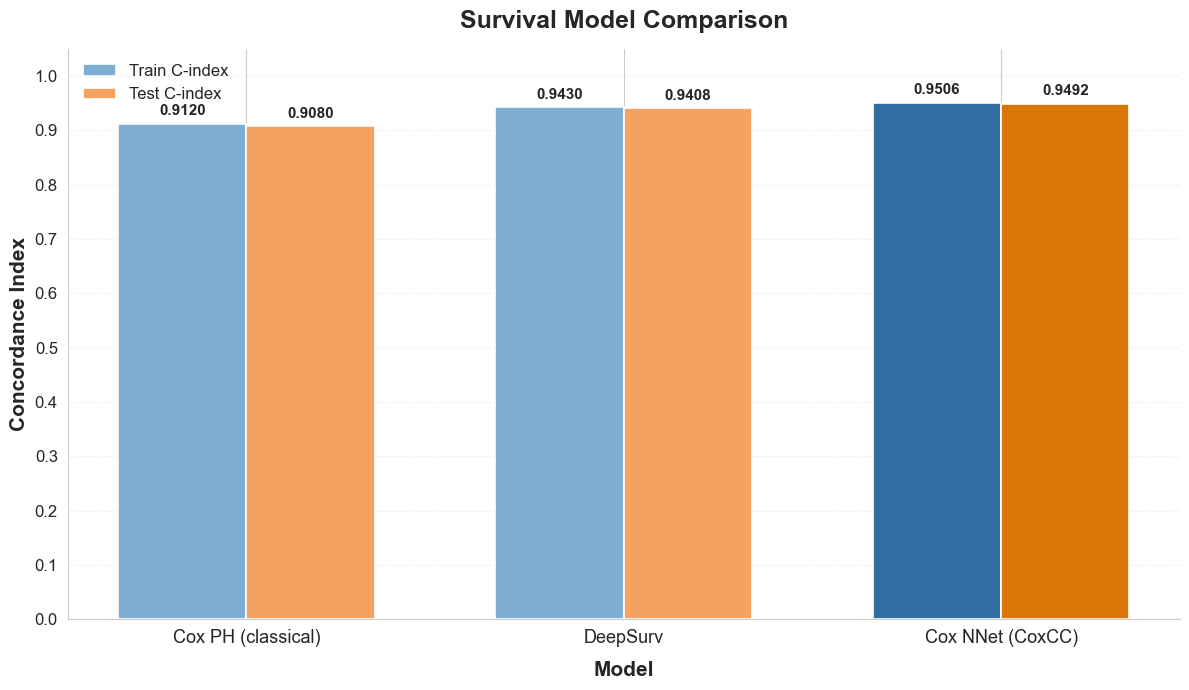

In [38]:
if HAS_PYCOX and len(surv_comparison) == 3:
    import os as _os

    surv_plot_df = pd.DataFrame(surv_comparison).sort_values(
        "C Index (test)", ascending=True
    ).reset_index(drop=True)

    models = surv_plot_df["Model"].tolist()
    train_ci = surv_plot_df["C Index (train)"].tolist()
    test_ci = surv_plot_df["C Index (test)"].tolist()

    x = np.arange(len(models))
    width = 0.34

    fig, ax = plt.subplots(figsize=(12, 7))

    train_colors = ["#7EAED3"] * len(models)
    test_colors  = ["#F4A261"] * len(models)

    train_colors[-1] = "#2F6DA3"
    test_colors[-1]  = "#D97706"

    bars1 = ax.bar(
        x - width/2, train_ci, width,
        label="Train C-index",
        color=train_colors,
        edgecolor="white",
        linewidth=1.2
    )
    bars2 = ax.bar(
        x + width/2, test_ci, width,
        label="Test C-index",
        color=test_colors,
        edgecolor="white",
        linewidth=1.2
    )

    ax.set_title("Survival Model Comparison", fontsize=18, fontweight="bold", pad=15)
    ax.set_ylabel("Concordance Index", fontsize=15, fontweight="bold")
    ax.set_xlabel("Model", fontsize=15, fontweight="bold", labelpad=10)

    ax.set_xticks(x)
    ax.set_xticklabels(models, fontsize=13)
    ax.tick_params(axis="y", labelsize=12)

    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.1))

    ax.grid(axis="y", linestyle="--", alpha=0.25)
    ax.set_axisbelow(True)

    ax.legend(fontsize=12, frameon=False, loc="upper left")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    for bar in bars1:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    for bar in bars2:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.01,
            f"{bar.get_height():.4f}",
            ha="center",
            va="bottom",
            fontsize=11,
            fontweight="bold"
        )

    plt.tight_layout()

    _vis_dir = _os.path.join(str(PROJECT_ROOT), "visuals")
    _os.makedirs(_vis_dir, exist_ok=True)
    plt.savefig(
        _os.path.join(_vis_dir, "24_survival_model_comparison.png"),
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )
    print("Saved: visuals/24_survival_model_comparison.png")

    plt.show()

### Interpretation

The concordance index (C-index) measures how well each model ranks machines by
risk. A C-index of 1.0 means perfect ranking and 0.5 means random chance.

All three models achieved strong C-index scores above 0.90 on the test set,
indicating that this dataset contains clear survival signals that even a linear
model can capture well. The deep learning models (DeepSurv and Cox NNet) scored
higher than Cox PH, suggesting that there are some non-linear risk patterns in
the data that a neural network can exploit.

However, the practical question is whether the improvement justifies the loss of
interpretability. Cox PH gives exact hazard ratios per covariate, meaning operators
can see precisely how each sensor variable affects failure risk. DeepSurv and Cox NNet
produce risk scores from neural networks whose internal weights cannot be translated
into the same kind of actionable, per-variable statements. For a dashboard designed
to help maintenance operators make decisions, that transparency is more valuable than
a 0.04 improvement in ranking accuracy.


## 18. Summary

### What was built
A survival analysis pipeline that estimates machine survival probability as a function of
tool wear (proxy time), stratified by machine type and conditioned on sensor covariates.
Three survival regression models were compared: classical Cox PH, DeepSurv, and Cox NNet.

### Key findings

- **Kaplan Meier:** Population level survival curves show the overall probability of
  a machine surviving beyond a given wear level. Stratification by type reveals distinct
  survival profiles across quality tiers.
- **Log-Rank Tests:** Statistical testing confirms that the observed differences between
  KM curves by machine type are statistically significant (p = 0.0058).
- **Cox PH (Type-Specific):** Three separate Cox models were fitted by machine type.
  Air temperature consistently showed the strongest hazard effect (HR = 2.93 for Type H,
  2.43 for Type M, 1.32 for Type L). Torque showed a consistent HR of approximately
  1.19 to 1.24 across all types. All three models achieved concordance of 0.89 or higher.

### Survival model comparison

| Model              | C-Index (Train) | C-Index (Test) |
|:-------------------|:---------------:|:--------------:|
| Cox PH (classical) | 0.9120          | 0.9080         |
| DeepSurv           | 0.9430          | 0.9408         |
| Cox NNet (CoxCC)   | 0.9506          | 0.9492         |

All three models achieved strong discriminative performance (C-index above 0.90).
Cox NNet achieved the highest test C-index (0.9492), followed by DeepSurv (0.9408)
and Cox PH (0.9080).

Despite Cox NNet and DeepSurv scoring higher on the C-index, we retained Cox PH for
the dashboard. Cox PH produces exact, per-covariate hazard ratios directly from its
model coefficients. For example, it tells operators that each 1 Kelvin increase in air
temperature nearly triples the failure hazard for Type H machines (HR = 2.93). Neither
DeepSurv nor Cox NNet can provide this level of direct interpretability because their
internal neural network weights do not map to per-covariate hazard statements.

Post-hoc explainability techniques such as SHAP could be applied to the deep learning
models, but these are approximations rather than exact model properties, and they would
likely produce the same feature rankings that our SHAP analysis on the classification
model already established in Notebook 08.

The gap between Cox PH (0.908) and Cox NNet (0.949) is 0.041. While meaningful, Cox PH
at 0.908 is already well above the 0.85 threshold generally considered strong in survival
analysis literature. The interpretability tradeoff favors Cox PH for an operator facing
dashboard that needs transparent, actionable explanations.

### Dashboard integration
The dashboard uses Cox PH for the Page 3 survival panel because it provides hazard
ratios that operators can understand and act on. The comparison documented above
serves as evidence that this choice prioritizes interpretability while still
maintaining strong predictive accuracy.
